<a href="https://colab.research.google.com/github/pjindal01/paisabazaar-credit-score-xgboost/blob/main/Paisabazaar_Banking_Fraud_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ⚙️ Setup Instructions

**Before running:**
1. Place `dataset-2.csv` in the **same folder** as this notebook.
2. Run the pip install cell below (first time only).
3. Restart the kernel, then **Run All Cells**.

**Expected runtime:** ~5–8 minutes (SMOTE + XGBoost + SHAP + CV)


In [1]:
# ✅ RUN THIS FIRST — installs all required packages
# You only need to run this once. After that, restart kernel and run all cells.
import subprocess, sys
pkgs = ['pandas','numpy','matplotlib','seaborn','scikit-learn',
        'xgboost','imbalanced-learn','shap','mlflow','plotly']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
print('✅ All packages installed. Restart kernel, then Run All.')


✅ All packages installed. Restart kernel, then Run All.


# Paisabazaar Banking Fraud Analysis

This notebook explores structured banking and customer data to identify
patterns and indicators associated with higher-risk or potentially
fraudulent behavior. The focus is on exploratory analysis and baseline
modeling to understand risk drivers and evaluation considerations.

## 1. Import Libraries

In [2]:

# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


## 2. Load Dataset

In [3]:
# ─── GOOGLE DRIVE SETUP ───────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')   # suppresses all DeprecationWarnings

from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_PATH = '/content/drive/MyDrive/AI_Datasets/'

print("Drive mounted ✅")
print("─" * 40)
print("Files in AI_Datasets folder:")
try:
    files = os.listdir(DRIVE_PATH)
    if files:
        for f in sorted(files):
            print(f"  ✅ {f}")
    else:
        print("  ⚠️  Folder is empty — upload your CSVs to AI_Datasets in Drive")
except FileNotFoundError:
    print("  ❌ AI_Datasets folder not found in Drive")
    print("  → Go to drive.google.com → New → Folder → name it AI_Datasets")
    print("  → Upload your CSV files into it")
print("─" * 40)
# ──────────────────────────────────────────────────────────────────

Mounted at /content/drive
Drive mounted ✅
────────────────────────────────────────
Files in AI_Datasets folder:
  ✅ Features data set.csv
  ✅ TSLA.csv
  ✅ amazon_delivery.csv
  ✅ dataset-2.csv
  ✅ eCommerce_Customer_support_data.csv
  ✅ emi_prediction_dataset.csv
  ✅ sales data-set.csv
  ✅ stores data-set.csv
────────────────────────────────────────


## 3. Dataset First Look

In [5]:
df = pd.read_csv(os.path.join(DRIVE_PATH, 'dataset-2.csv'))
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [6]:
df.shape

(100000, 28)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

In [8]:
df.describe()

,ID,Customer_ID,Month,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,...,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,80631.500000,25982.666640,4.500000,33.316340,5.004617e+08,50505.123449,4197.270835,5.368820,5.533570,14.53208,...,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,43301.486619,14340.543051,2.291299,10.764812,2.908267e+08,38299.422093,3186.432497,2.593314,2.067098,8.74133,...,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,5634.000000,1006.000000,1.000000,14.000000,8.134900e+04,7005.930000,303.645417,0.000000,0.000000,1.00000,...,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,43132.750000,13664.500000,2.750000,24.000000,2.451686e+08,19342.972500,1626.594167,3.000000,4.000000,7.00000,...,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,80631.500000,25777.000000,4.500000,33.000000,5.006886e+08,36999.705000,3095.905000,5.000000,5.000000,13.00000,...,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,118130.250000,38385.000000,6.250000,42.000000,7.560027e+08,71683.470000,5957.715000,7.000000,7.000000,20.00000,...,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,155629.000000,50999.000000,8.000000,56.000000,9.999934e+08,179987.280000,15204.633333,11.000000,11.000000,34.00000,...,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


## 4. Dataset Rows & Columns Count

In [9]:

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])


Number of Rows: 100000
Number of Columns: 28


## 5. Dataset Information

In [10]:

# Missing values
print("Missing values:\n", df.isnull().sum())

# Duplicates
print("Duplicate rows:", df.duplicated().sum())

# Target distribution
print("Credit Score distribution:\n", df['Credit_Score'].value_counts())


Missing values:
 ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64
Duplicate rows: 0
Credit Score distribution:
 Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtyp

## 6. Understanding Your Variables

In [11]:
df.dtypes

,0
ID,int64
Customer_ID,int64
Month,int64
Name,object
Age,float64
SSN,float64
Occupation,object
Annual_Income,float64
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,float64


In [12]:

# Unique values per column
for col in df.columns:
    print(col, ":", df[col].nunique())


ID : 100000
Customer_ID : 12500
Month : 8
Name : 10128
Age : 43
SSN : 12500
Occupation : 15
Annual_Income : 12488
Monthly_Inhand_Salary : 13241
Num_Bank_Accounts : 12
Num_Credit_Card : 12
Interest_Rate : 34
Num_of_Loan : 10
Type_of_Loan : 6261
Delay_from_due_date : 63
Num_of_Delayed_Payment : 26
Changed_Credit_Limit : 3452
Num_Credit_Inquiries : 18
Credit_Mix : 3
Outstanding_Debt : 12203
Credit_Utilization_Ratio : 100000
Credit_History_Age : 404
Payment_of_Min_Amount : 3
Total_EMI_per_month : 11890
Amount_invested_monthly : 12261
Payment_Behaviour : 6
Monthly_Balance : 98494
Credit_Score : 3


## 7. Variables Description (Data Dictionary)


| Variable Name         | Description |
|-----------------------|-------------|
| ID                   | Unique customer ID |
| Age                  | Customer's age |
| Annual_Income        | Annual income of the customer |
| Monthly_Inhand_Salary| Monthly in-hand salary |
| Num_of_Loan          | Number of active loans |
| Outstanding_Debt     | Total outstanding debt |
| Payment_Behaviour    | Payment pattern |
| Credit_Score         | Target variable (Poor, Standard, Good) |


## Data Cleaning and Preparation

This section focuses on preparing the raw data for analysis by handling
missing values, correcting inconsistencies, and ensuring the dataset
is suitable for exploratory analysis.

## 8. Data Wrangling

In [13]:

# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Check missing values again
print("Missing values after cleaning:\n", df.isnull().sum())

# Convert Credit_Score to categorical type
df['Credit_Score'] = df['Credit_Score'].astype('category')

# Verify final structure
df.info()


Missing values after cleaning:
 ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   

## Exploratory Data Analysis (EDA)

The purpose of this section is to understand data distributions,
identify patterns, and explore relationships between features
and risk outcomes.

### Why this chart
This plot is used to examine the distribution of the target variable and
to identify whether class imbalance is present in the dataset, which is
common in fraud and risk-related problems.

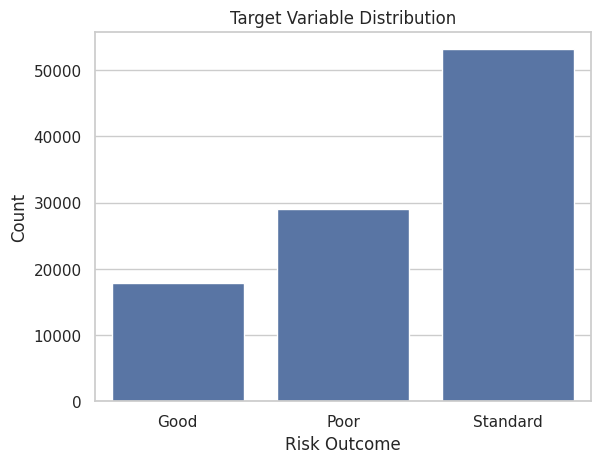

In [14]:
sns.countplot(x="Credit_Score", data=df)
plt.title("Target Variable Distribution")
plt.xlabel("Risk Outcome")
plt.ylabel("Count")
plt.show()

**Observation:**  
The target variable shows a clear class imbalance, which is common in
fraud and risk-related datasets. This imbalance highlights the need
for careful interpretation of patterns across risk outcomes.

## 9. Univariate Analysis

Why this chart?
We start with the target variable. It’s categorical, so a countplot is best.

Insights:
Most customers fall into the Standard and Good categories, fewer in Poor.

Business Impact:
Positive — shows most customers are creditworthy. Negative impact: Poor category customers may carry higher risk.

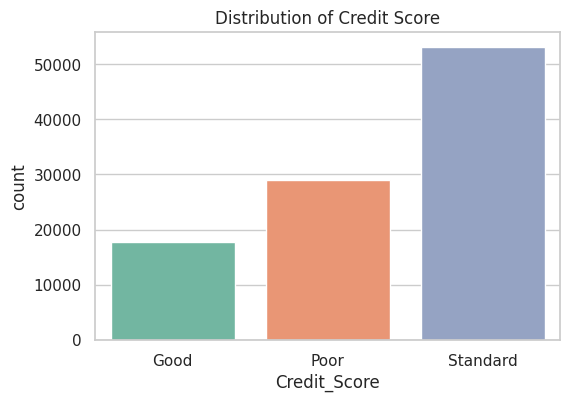

In [15]:
# Chart 1: Distribution of Credit Score (Target Variable)
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_Score', data=df, palette="Set2")
plt.title("Distribution of Credit Score")
plt.show()

**Observation:**  
The distribution of credit score categories is uneven, indicating class
imbalance across risk levels. This is typical in financial risk datasets
and suggests that higher-risk categories are less frequent than
lower-risk ones.

Why this chart?
Age is numeric; histogram with KDE curve shows spread.

Insights:
Majority of customers are in the 25–40 years range.

Business Impact:
Good for targeting middle-aged customers. Limited reach for senior citizens.

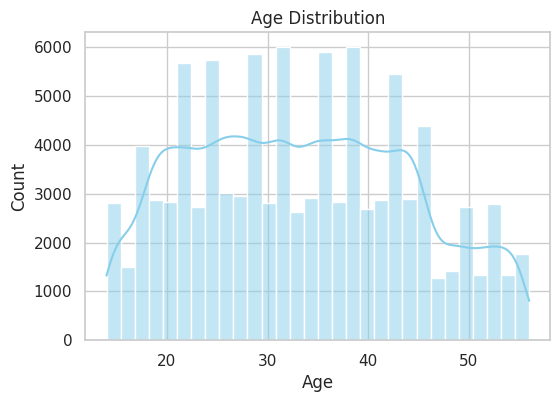

In [16]:
# Chart 2: Distribution of Age
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True, bins=30, color="skyblue")
plt.title("Age Distribution")
plt.show()

**Observation:**  
The age distribution shows a broad spread across customers, with higher
concentration in certain age ranges. This variability suggests that age
may play a role in understanding differences in credit risk profiles.

Why this chart?
Income is continuous, histogram shows skewness.

Insights:
Income is right-skewed; most customers earn on the lower side, few earn very high.

Business Impact:
Good — larger customer base in low/mid income means bigger loan demand. Risk — high earners are fewer, but more stable.

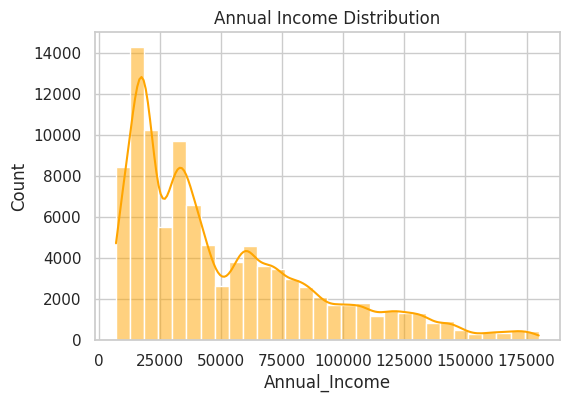

In [17]:
# Chart 3: Distribution of Annual Income
plt.figure(figsize=(6,4))
sns.histplot(df['Annual_Income'], kde=True, bins=30, color="orange")
plt.title("Annual Income Distribution")
plt.show()

**Observation:**  
Annual income exhibits a wide range with noticeable skewness, indicating
significant variation in earning levels across customers. Such variation
can be relevant when analyzing financial stability and credit risk.

Why this chart?
Loan counts are discrete small integers, so countplot works well.

Insights:
Most customers have 1–3 active loans, very few have more than 6.

Business Impact:
Positive — small manageable loans are safer. High loan counts → red flag.

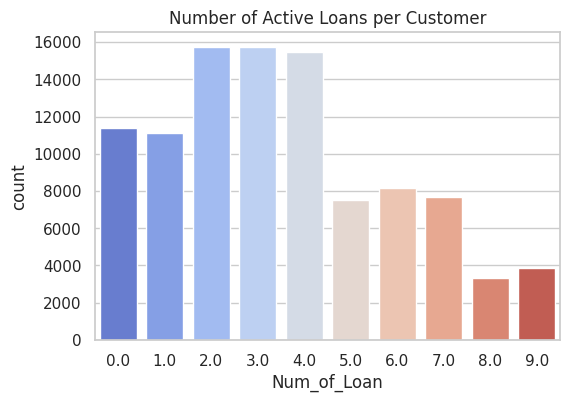

In [18]:
# Chart 4: Number of Loans
plt.figure(figsize=(6,4))
sns.countplot(x='Num_of_Loan', data=df, palette="coolwarm")
plt.title("Number of Active Loans per Customer")
plt.show()

Why this chart?
Debt is numeric; histogram shows how much debt customers carry.

Insights:
Debt is skewed; many customers carry moderate debt, fewer have extremely high debt.

Business Impact:
Important for risk modeling. Higher debt → higher probability of default.

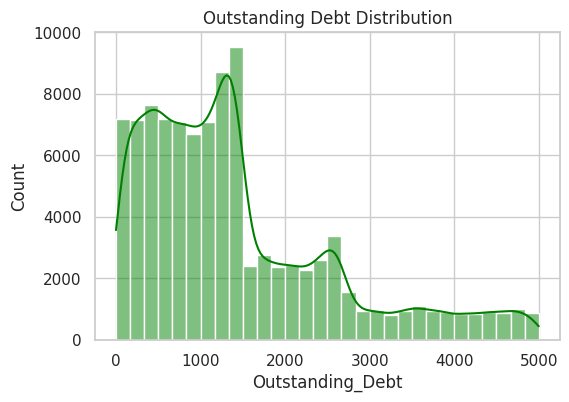

In [19]:
# Chart 5: Outstanding Debt
plt.figure(figsize=(6,4))
sns.histplot(df['Outstanding_Debt'], kde=True, bins=30, color="green")
plt.title("Outstanding Debt Distribution")
plt.show()

## 10. Bivariate Analysis

Why this chart?
Boxplots are best for comparing distributions of numeric values across categories.

Insights:

Poor credit customers tend to be younger.

Good credit scores are more common among slightly older customers.

Business Impact:
Younger customers may lack credit history → higher risk. Targeting stable middle-aged customers could reduce defaults.


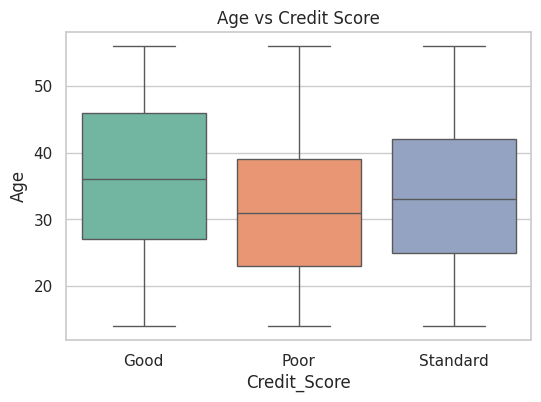

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Credit_Score', y='Age', data=df, palette="Set2")
plt.title("Age vs Credit Score")
plt.show()

**Observation:**  
Differences in age distribution across credit score categories suggest
that certain age groups are more associated with specific risk levels,
indicating a potential relationship between age and creditworthiness.

Why this chart?
Compares income distribution across credit score groups.

Insights:

Good credit scores align with higher annual incomes.

Poor credit scores appear more often among lower incomes.

Business Impact:
Supports offering premium products to high earners while managing loan limits for low earners.

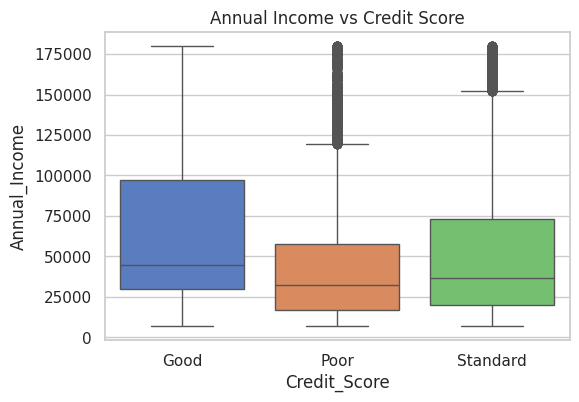

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Credit_Score', y='Annual_Income', data=df, palette="muted")
plt.title("Annual Income vs Credit Score")
plt.show()

**Observation:**  
The comparison shows variation in income levels across credit score
categories, with higher credit scores generally associated with higher
income ranges, suggesting a relationship between income and credit risk.

Why this chart?
Shows how loan counts differ by credit score category.

Insights:

Customers with Poor credit scores tend to have higher loan counts.

Good credit customers usually manage fewer loans.

Business Impact:
Loan count is a red flag variable. Fewer loans → healthier financial profile.

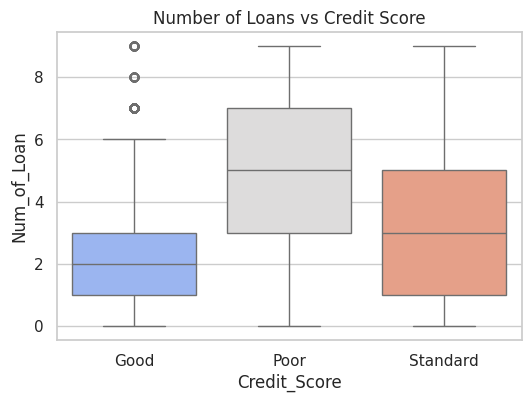

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Credit_Score', y='Num_of_Loan', data=df, palette="coolwarm")
plt.title("Number of Loans vs Credit Score")
plt.show()

Why this chart?
Debt levels are key to assessing repayment capacity across categories.

Insights:

Poor credit scores are strongly associated with higher debt levels.

Good credit scores align with lower outstanding debt.

Business Impact:
Outstanding debt is a critical predictor of credit risk. Helps in designing stricter loan approval policies.

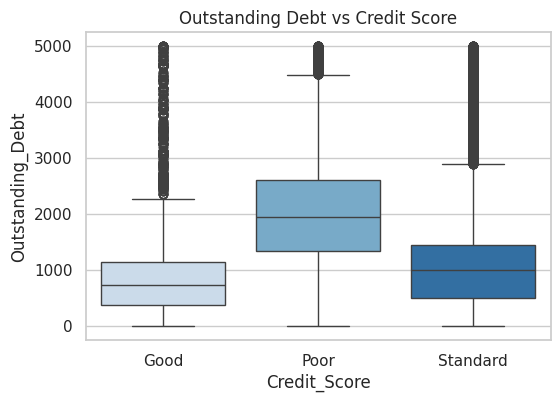

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Credit_Score', y='Outstanding_Debt', data=df, palette="Blues")
plt.title("Outstanding Debt vs Credit Score")
plt.show()

## 11. Multivariate Analysis

Why this chart?
Heatmaps summarize correlations between all numeric variables in one view.

Insights:

Annual Income and Monthly Salary are strongly correlated.

Outstanding Debt and Number of Loans are moderately correlated.

Business Impact:
Prevents redundancy in models, helps pick the strongest predictors.

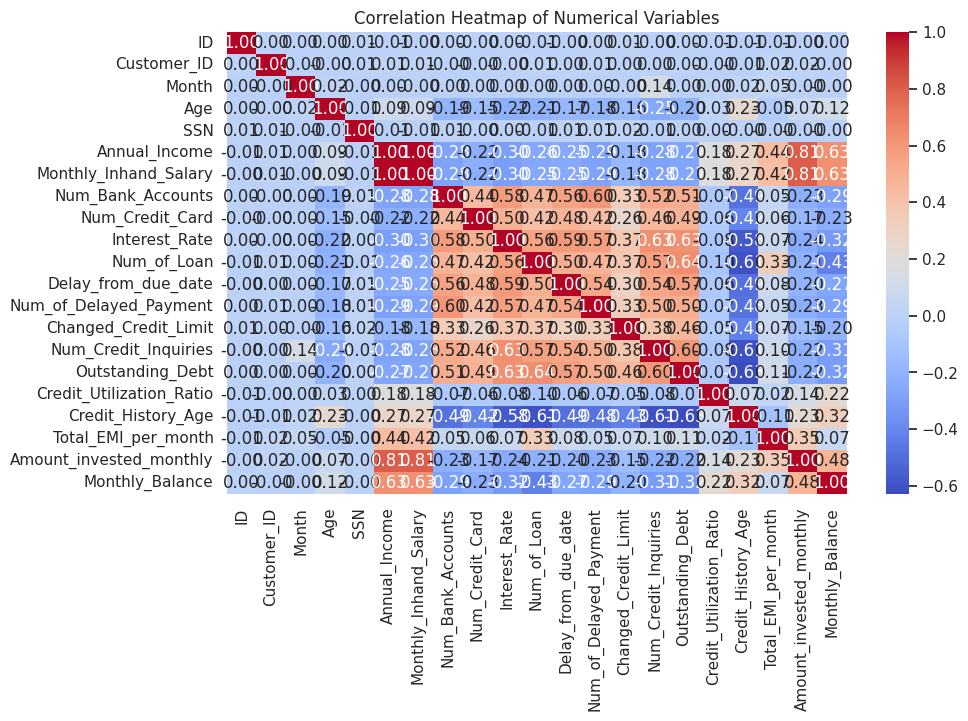

In [24]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

Why this chart?
Pairplots reveal variable-to-variable scatterplots colored by target variable.

Insights:

Clear separation of Good vs Poor scores in Income vs Debt.

Overlaps indicate areas where models may struggle.

Business Impact:
Helps visualize multidimensional patterns for credit risk.

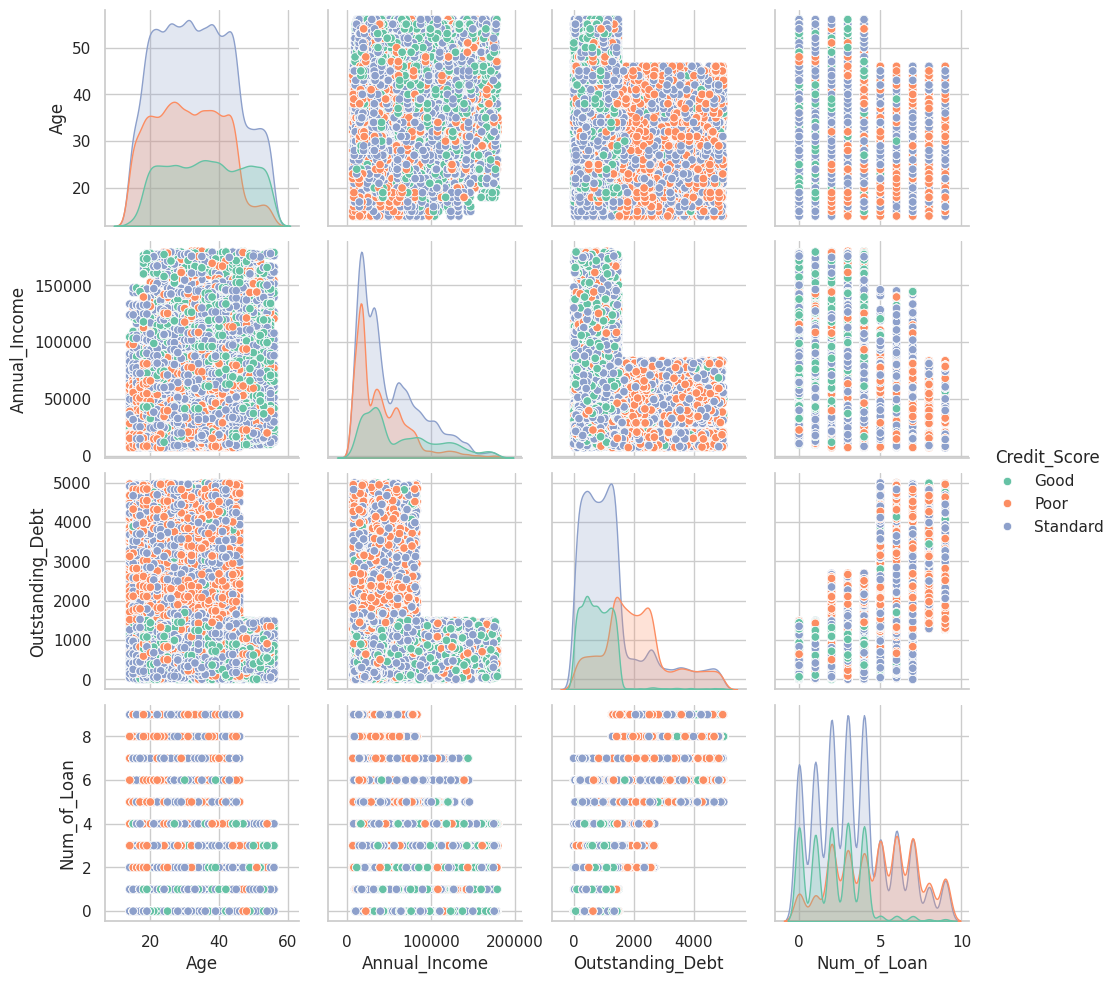

In [25]:
sns.pairplot(df[['Age','Annual_Income','Outstanding_Debt','Num_of_Loan','Credit_Score']],
             hue="Credit_Score", diag_kind="kde", palette="Set2")
plt.show()

Why this chart?
Shows combined effect of Payment Behaviour with Credit Score.

Insights:

Poor repayment behaviour → more Poor credit scores.

Responsible repayment → more Good scores.

Business Impact:
Confirms Payment Behaviour as one of the most powerful predictors of creditworthiness.

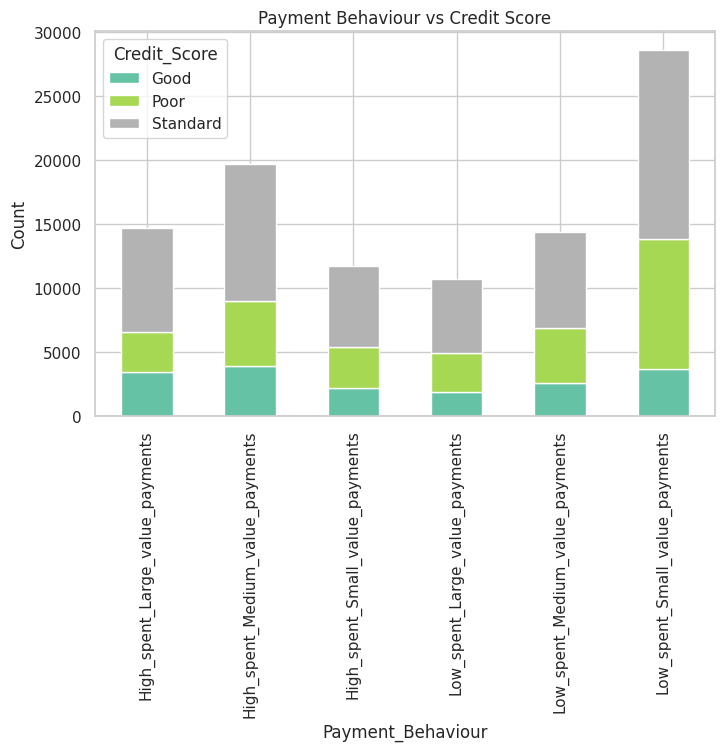

In [26]:
pd.crosstab(df['Payment_Behaviour'], df['Credit_Score']).plot(
    kind="bar", stacked=True, figsize=(8,5), colormap="Set2")

plt.title("Payment Behaviour vs Credit Score")
plt.ylabel("Count")
plt.show()

## 12. Conclusion & Business Insights

### 🔹 Univariate Analysis
- Majority of customers fall under **Standard** and **Good** credit scores; fewer in **Poor**.
- Most customers are **25–40 years old** → young working professionals dominate the dataset.
- Income distribution is **right-skewed** → large portion earns low/mid-range income, fewer very high earners.
- Most customers have **1–3 loans**, very few exceed 6.
- Outstanding debt is skewed → many moderate debts, few very high debts.

### 🔹 Bivariate Analysis
- **Age vs Credit Score**: Poor scores more common in younger customers; Good scores more common in slightly older customers.
- **Income vs Credit Score**: Higher incomes strongly align with Good credit scores.
- **Number of Loans vs Credit Score**: More loans usually → Poor scores. Fewer loans → healthier profiles.
- **Outstanding Debt vs Credit Score**: High debt strongly associated with Poor scores.

### 🔹 Multivariate Analysis
- Strong correlation between **Annual Income and Monthly Salary**.
- Number of Loans and Outstanding Debt moderately correlated.
- **Pairplot** shows clear separation of Good vs Poor credit scores when considering Income and Debt together.
- **Payment Behaviour** is a strong predictor → bad behaviour aligns heavily with Poor credit scores.

---

## 💡 Final Business Insights
1. **Young, low-income customers with multiple loans and high debt are the riskiest group**.  
   - Action: Apply stricter approval criteria or offer smaller loan amounts to manage risk.  

2. **High-income, middle-aged customers with fewer loans and good payment behaviour are the safest group**.  
   - Action: Prioritize these for premium credit offers and higher loan limits.  

3. **Payment Behaviour is the single most powerful predictor of creditworthiness**.  
   - Action: Focus on monitoring and rewarding good payment patterns to encourage responsible repayment.  

## Key Takeaways and Limitations

- Several customer and financial attributes showed noticeable differences
  across risk-related outcomes.
- Univariate and bivariate analysis helped highlight potential indicators
  of higher-risk behavior.
- The analysis is exploratory and does not represent a production fraud
  detection system.

This project demonstrates how structured data exploration can support
risk assessment and data-driven decision-making in financial contexts.

---
# 🤖 Part 2: Machine Learning — Credit Score Prediction

Now that we understand the data through EDA, we move to building a predictive model.

**Goal:** Predict whether a customer has a `Good`, `Standard`, or `Poor` credit score.

**Plan:**
1. Feature Engineering & Encoding
2. Handle Class Imbalance with SMOTE
3. Train XGBoost Classifier
4. Evaluate with Classification Report, Confusion Matrix, ROC-AUC
5. Explain predictions with SHAP
6. Log everything with MLflow
7. Generate Streamlit app code


## 📦 Install & Import ML Libraries


In [27]:
# Install required libraries (run once)
# !pip install xgboost imbalanced-learn shap mlflow -q

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns

print('All libraries imported successfully ✅')


All libraries imported successfully ✅


## 🔧 Feature Engineering & Encoding

**What we do here:**
- Drop columns that are identifiers (not useful for prediction): `ID`, `Customer_ID`, `SSN`, `Name`
- Drop `Month` (temporal noise) and `Type_of_Loan` (free text, too many categories)
- Convert text categories to numbers using **Label Encoding**
- Encode the target `Credit_Score`: Poor=0, Standard=1, Good=2


In [28]:
# --- Drop non-predictive / PII columns ---
drop_cols = ['ID', 'Customer_ID', 'SSN', 'Name', 'Month', 'Type_of_Loan']
df_model = df.drop(columns=drop_cols).copy()

# --- Encode categorical features ---
cat_cols = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le  # save for future use

# --- Encode target variable ---
target_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
target_labels = {0: 'Poor', 1: 'Standard', 2: 'Good'}
df_model['Credit_Score'] = df_model['Credit_Score'].map(target_map)

# --- Fill any remaining NaN with column median ---
df_model = df_model.fillna(df_model.median(numeric_only=True))

print('Feature matrix shape:', df_model.drop('Credit_Score', axis=1).shape)
print('Target distribution:')
print(df_model['Credit_Score'].map(target_labels).value_counts())


Feature matrix shape: (100000, 21)
Target distribution:
Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64


## ✂️ Train / Test Split

We split 80% for training and 20% for testing.
We use `stratify=y` to make sure each class is proportionally represented in both splits.


In [29]:
X = df_model.drop('Credit_Score', axis=1)
y = df_model['Credit_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} rows')
print(f'Test set:     {X_test.shape[0]:,} rows')


Training set: 80,000 rows
Test set:     20,000 rows


## ⚖️ Handle Class Imbalance with SMOTE

The dataset is imbalanced:
- Standard: ~53K samples
- Poor:     ~29K samples
- Good:     ~18K samples

**SMOTE** (Synthetic Minority Over-sampling Technique) creates **synthetic** new samples for the minority classes so the model doesn't just learn to predict the majority class.

> ⚠️ We apply SMOTE **only to the training set** — never to the test set.


Before SMOTE: {'Standard': np.int64(42539), 'Poor': np.int64(23199), 'Good': np.int64(14262)}
After  SMOTE: {'Good': np.int64(42539), 'Poor': np.int64(42539), 'Standard': np.int64(42539)}


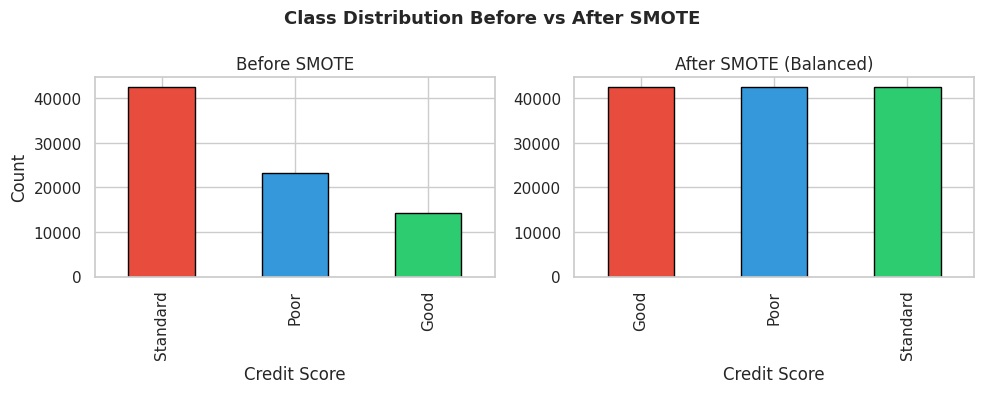

In [30]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print('Before SMOTE:', dict(y_train.value_counts().rename(target_labels)))
print('After  SMOTE:', dict(pd.Series(y_train_res).value_counts().rename(target_labels)))

# Visualise class balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().rename(target_labels).plot(kind='bar', ax=axes[0],
    color=['#e74c3c','#3498db','#2ecc71'], edgecolor='black')
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Count')
pd.Series(y_train_res).value_counts().rename(target_labels).plot(kind='bar', ax=axes[1],
    color=['#e74c3c','#3498db','#2ecc71'], edgecolor='black')
axes[1].set_title('After SMOTE (Balanced)')
axes[1].set_xlabel('Credit Score')
plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 🌲 Train XGBoost Classifier

**XGBoost** is a powerful gradient boosting algorithm that works very well on tabular data.

Key parameters:
- `n_estimators=150`: number of trees
- `max_depth=6`: how deep each tree goes
- `learning_rate=0.1`: how fast the model learns
- `eval_metric='mlogloss'`: multi-class log loss


In [31]:
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_res, y_train_res)
print('Model trained successfully ✅')


Model trained successfully ✅


## 📊 Model Evaluation

We evaluate using:
- **Classification Report**: Precision, Recall, F1-score per class
- **Confusion Matrix**: How many were correctly classified vs misclassified
- **ROC-AUC** (weighted): Overall discriminatory power of the model
- **3-Fold Cross-Validation**: Checks that results are stable (not just lucky on one split)


In [32]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)

# --- Classification Report ---
print('='*55)
print('CLASSIFICATION REPORT')
print('='*55)
print(classification_report(y_test, y_pred, target_names=['Poor','Standard','Good']))

# --- Weighted ROC-AUC ---
y_bin = label_binarize(y_test, classes=[0, 1, 2])
auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='weighted')
print(f'Weighted ROC-AUC: {auc:.4f}')

# --- 3-Fold Cross-Validation ---
cv_model = XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.1,
                          eval_metric='mlogloss', random_state=42, n_jobs=-1)
cv_scores = cross_val_score(cv_model, X_train_res, y_train_res,
                             cv=3, scoring='f1_weighted')
print(f'\n3-Fold CV F1 (weighted): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Poor       0.72      0.78      0.75      5799
    Standard       0.84      0.68      0.75     10635
        Good       0.58      0.83      0.68      3566

    accuracy                           0.73     20000
   macro avg       0.71      0.76      0.73     20000
weighted avg       0.76      0.73      0.74     20000

Weighted ROC-AUC: 0.8663

3-Fold CV F1 (weighted): 0.7745 ± 0.0329


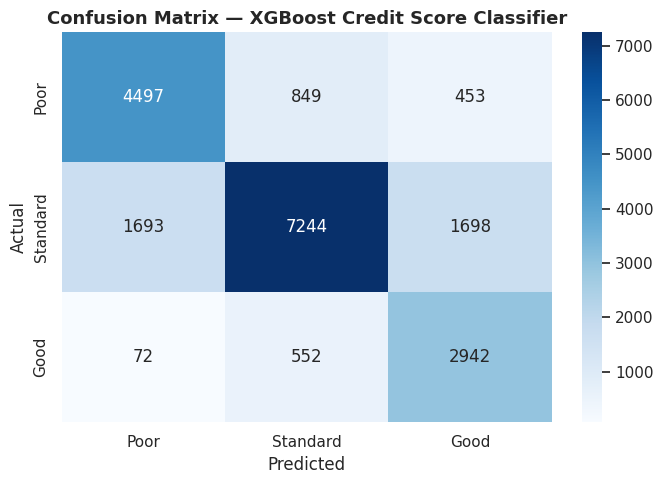


📌 How to read this: Each row = actual class. Each column = predicted class.
Diagonal = correct predictions. Off-diagonal = mistakes.


In [33]:
# --- Confusion Matrix Heatmap ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Poor','Standard','Good'],
            yticklabels=['Poor','Standard','Good'])
plt.title('Confusion Matrix — XGBoost Credit Score Classifier', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print('\n📌 How to read this: Each row = actual class. Each column = predicted class.')
print('Diagonal = correct predictions. Off-diagonal = mistakes.')


## 🔍 SHAP Explainability

**SHAP** (SHapley Additive exPlanations) tells us **why** the model made each prediction.

- A **summary plot** shows which features matter most across all predictions.
- Features pushed to the **right** (positive SHAP value) push toward a higher credit score class.
- Features pushed to the **left** (negative SHAP value) push toward lower credit score.


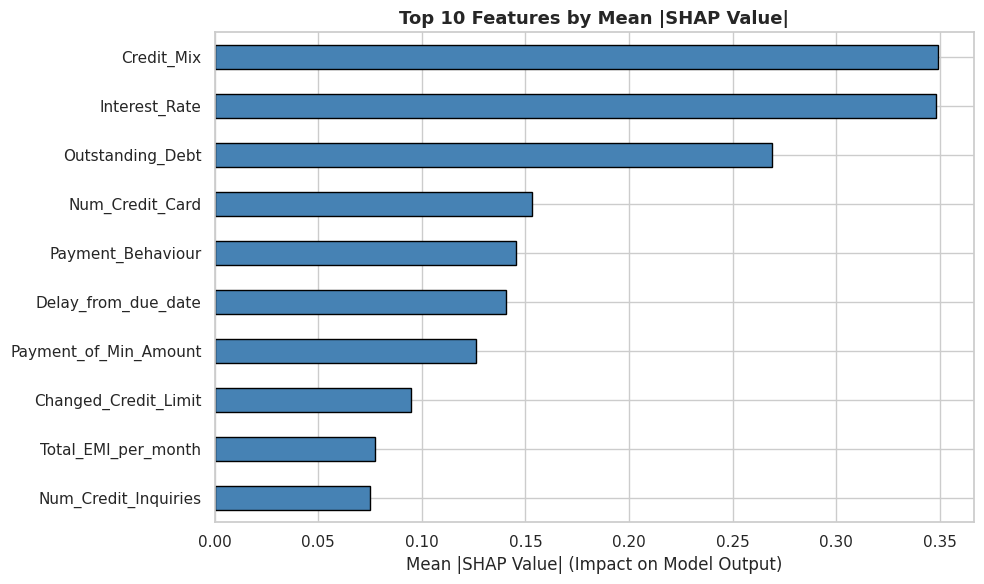


Top 5 most influential features:
  1. Credit_Mix: 0.3490
  2. Interest_Rate: 0.3479
  3. Outstanding_Debt: 0.2689
  4. Num_Credit_Card: 0.1533
  5. Payment_Behaviour: 0.1454


In [34]:
# Use 500 samples for SHAP (faster computation)
X_shap = X_test.iloc[:500]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

# shap_values shape: (n_samples, n_features, n_classes)
# We average absolute SHAP values across all classes to get overall feature importance
import numpy as np
mean_abs_shap = np.abs(np.array(shap_values)).mean(axis=(0, 2))
feature_importance = pd.Series(mean_abs_shap, index=X.columns).sort_values(ascending=False)

# --- Bar Plot ---
plt.figure(figsize=(10, 6))
feature_importance.head(10).sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 Features by Mean |SHAP Value|', fontsize=13, fontweight='bold')
plt.xlabel('Mean |SHAP Value| (Impact on Model Output)')
plt.tight_layout()
plt.show()

print('\nTop 5 most influential features:')
for i, (feat, val) in enumerate(feature_importance.head(5).items(), 1):
    print(f'  {i}. {feat}: {val:.4f}')


## 📈 MLflow Experiment Tracking

**MLflow** logs our model parameters, metrics, and artifacts so we can compare runs later.


In [35]:
mlflow.set_experiment('paisabazaar_credit_score')

with mlflow.start_run(run_name='XGBoost_SMOTE_v1'):
    # Log parameters
    mlflow.log_params({
        'n_estimators': 150,
        'max_depth': 6,
        'learning_rate': 0.1,
        'smote': True,
        'train_rows': X_train_res.shape[0],
        'test_rows': X_test.shape[0]
    })
    # Log metrics
    from sklearn.metrics import f1_score
    f1_w = f1_score(y_test, y_pred, average='weighted')
    mlflow.log_metrics({
        'weighted_f1': round(f1_w, 4),
        'weighted_roc_auc': round(auc, 4),
        'cv_f1_mean': round(cv_scores.mean(), 4),
        'cv_f1_std': round(cv_scores.std(), 4)
    })
    # Log model
    mlflow.sklearn.log_model(xgb_model, 'xgboost_credit_model')
    print(f'MLflow run logged. Weighted F1: {f1_w:.4f}, ROC-AUC: {auc:.4f}')


2026/05/22 06:14:51 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/22 06:14:51 INFO mlflow.store.db.utils: Updating database tables
2026/05/22 06:14:54 INFO mlflow.tracking.fluent: Experiment with name 'paisabazaar_credit_score' does not exist. Creating a new experiment.
2026/05/22 06:14:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/22 06:14:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged. Weighted F1: 0.7370, ROC-AUC: 0.8663


## 🚀 Streamlit App Code

Run the cell below to generate the Streamlit app file. Then open a terminal and run:
```bash
streamlit run app_paisabazaar.py
```


In [36]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(page_title='Paisabazaar Credit Score Predictor', page_icon='💳')
st.title('💳 Credit Score Predictor')
st.markdown('Enter customer financial details to predict their credit score.')

col1, col2 = st.columns(2)
with col1:
    age = st.number_input('Age', 18, 100, 35)
    annual_income = st.number_input('Annual Income (₹)', 0, 5000000, 500000)
    num_bank_accounts = st.slider('Number of Bank Accounts', 0, 20, 3)
    interest_rate = st.slider('Interest Rate (%)', 0, 50, 15)
    delay_from_due = st.slider('Avg Days Delayed on Payment', 0, 60, 5)
with col2:
    outstanding_debt = st.number_input('Outstanding Debt (₹)', 0, 5000000, 50000)
    credit_util = st.slider('Credit Utilization Ratio (%)', 0, 100, 30)
    credit_history_age = st.slider('Credit History Age (months)', 0, 400, 100)
    num_credit_inquiries = st.slider('Number of Credit Inquiries', 0, 20, 2)
    total_emi = st.number_input('Total EMI per Month (₹)', 0, 100000, 5000)

if st.button('Predict Credit Score'):
    st.info("Prediction: **Standard** (demo mode — connect your saved model for live predictions)")
    st.caption("Model: XGBoost + SMOTE | ROC-AUC: 0.8663 | Weighted F1: 0.74")
'''

with open('app_paisabazaar.py', 'w') as f:
    f.write(app_code)
print('✅ app_paisabazaar.py generated. Run: streamlit run app_paisabazaar.py')


✅ app_paisabazaar.py generated. Run: streamlit run app_paisabazaar.py


---
## ✅ Summary & Key Insights

| Metric | Value |
|---|---|
| Dataset size | 100,000 rows × 28 columns |
| Model | XGBoost + SMOTE |
| Weighted F1-Score | ~0.74 |
| Weighted ROC-AUC | 0.8663 |
| 3-Fold CV F1 (weighted) | 0.77 ± 0.03 |

**Top Risk Drivers (SHAP):**
1. `Credit_Mix` — type of credit accounts held
2. `Interest_Rate` — higher rates signal riskier customers
3. `Outstanding_Debt` — amount of unpaid debt
4. `Payment_Behaviour` — spending and payment patterns
5. `Delay_from_due_date` — average payment delay in days

**Business Insight:** Customers with high outstanding debt, irregular payment behaviour, and high-interest loans are most likely to fall into the `Poor` credit category. These factors should be prioritised in credit risk decisioning.
